# Tarea 1: Análisis Exploratorio y Preparación de Datos

## 1. Carga de datos con Pandas

In [1]:
import pandas as pd

# Carga de los tres subconjuntos del dataset MLSUM en español
df_train = pd.read_csv('../MLSUM_dataset/es_train.csv')
df_val = pd.read_csv('../MLSUM_dataset/es_validation.csv')
df_test = pd.read_csv('../MLSUM_dataset/es_test.csv')

In [2]:
# Inspección rápida de las primeras filas y columnas (text, summary, topic)
print(f"Entrenamiento: {df_train.shape[0]} ejemplos")
print(df_train.head())

Entrenamiento: 266367 ejemplos
                                                text  \
0  De momento, no podemos responder a la pregunta...   
1  Los vuelos han venido registrando este viernes...   
2  El Gobierno turco ha anunciado que emprenderá ...   
3  La policía de Finlandia ha informado este vier...   
4  "Hemos descubierto un agujero vertical en la L...   

                                             summary  \
0  Sofres no ofrece datos por ser festivo.- Telec...   
1  El aeropuerto ha estado hasta las 15.00 con só...   
2  El origen de la leyenda, el san Nicolás histór...   
3  El hombre mató a su ex pareja, a cuatro person...   
4  El hueco en el subsuelo podría ofrecer refugio...   

                      topic  \
0         elpais actualidad   
1         elpais actualidad   
2         elpais actualidad   
3  internacional actualidad   
4       sociedad actualidad   

                                                 url  \
0  http://elpais.com/elpais/2010/01/01/actualidad...

## 2. Validación de la estructura

In [3]:
# Verificación de nulos: Asegúrate de que no haya noticias (text) o resúmenes (summary) vacíos
print("Nulos en el conjunto de entrenamiento:")
print(df_train[['text', 'summary']].isnull().sum())
print("\nNulos en el conjunto de validación:")
print(df_val[['text', 'summary']].isnull().sum())
print("\nNulos en el conjunto de prueba:")
print(df_test[['text', 'summary']].isnull().sum())

Nulos en el conjunto de entrenamiento:
text       0
summary    0
dtype: int64

Nulos en el conjunto de validación:
text       0
summary    0
dtype: int64

Nulos en el conjunto de prueba:
text       0
summary    0
dtype: int64


In [4]:
# Exploración de tópicos: Revisa la columna topic para ver si el dataset está balanceado
print("Distribución de tópicos en el conjunto de entrenamiento:")
print(df_train['topic'].value_counts())
print("\nDistribución de tópicos en el conjunto de validación:")
print(df_val['topic'].value_counts())
print("\nDistribución de tópicos en el conjunto de prueba:")
print(df_test['topic'].value_counts())

Distribución de tópicos en el conjunto de entrenamiento:
topic
elpais opinion                                  22774
cultura actualidad                              21361
ccaa catalunya                                  20097
politica actualidad                             19318
economia actualidad                             18646
                                                ...  
elpais mama_ya_lo_sabe_y_la_abuela_lo_intuia        1
brasil opinion                                      1
cat ciencia                                         1
cat economia                                        1
cat catalunya                                       1
Name: count, Length: 201, dtype: int64

Distribución de tópicos en el conjunto de validación:
topic
elpais opinion                     1573
politica actualidad                1031
economia actualidad                 854
ccaa madrid                         780
ccaa catalunya                      727
                                   ... 
soc

## 3. Preparación para Transformers

In [5]:
%pip install datasets

from datasets import Dataset, DatasetDict

# Conversión de Pandas a Dataset de Hugging Face
train_ds = Dataset.from_pandas(df_train)
val_ds = Dataset.from_pandas(df_val)
test_ds = Dataset.from_pandas(df_test)

# Organización en un único objeto para facilitar el entrenamiento
raw_datasets = DatasetDict({
    'train': train_ds,
    'validation': val_ds,
    'test': test_ds
})

print(raw_datasets)

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


DatasetDict({
    train: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
        num_rows: 266367
    })
    validation: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
        num_rows: 10358
    })
    test: Dataset({
        features: ['text', 'summary', 'topic', 'url', 'title', 'date'],
        num_rows: 13920
    })
})


## 4. Modelos estractivos

In [6]:
!pip install pandas matplotlib spacy scikit-learn datasets
!python -m spacy download es_core_news_sm

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 11.8 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 11.7 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.3 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 11.5 MB/s  0:00:00
   ---------------------------------------- 0.0/14.4 MB ? eta -:--:--
   ------ --------------------------------- 2.4/14.4 MB 11.7 MB/s eta 0:00:02
   ------------- -------------------------- 4.7/14.4 MB 11.7 MB/s eta 0:00:01
   ------------------- -------------------- 7.1/14.4 MB 11.8 MB/s eta 0:00:01
   -------------------------- ------------- 9.4/14.4 MB 11.8 MB/s eta 0:00:01
   -------------------------------- ------- 11.8/14.4 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------  14.2/14.4 MB 11.8 MB/s eta 0:00:01
   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     --------------------------------------- 0.0/12.9 MB 435.7 kB/s eta 0:00:30
     --------------------------------------- 0.1/12.9 MB 653.6 kB/s eta 0:00:20
     - -------------------------------------- 0.3/12.9 MB 2.3 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.9 MB 4.4 MB/s eta 0:00:03
     ---- ----------------------------------- 1.3/12.9 MB 5.7 MB/s eta 0:00:03
     ----- ---------------------------------- 1.8/12.9 MB 6.7 MB/s eta 0:00:02
     ------- -------------------------------- 2.4/12.9 MB 7.6 MB/s eta 0:00:02
     --------- ------------------------------ 3.0/12.9 MB 7.9 MB/s eta 0:00:02
     ---------- ----------------------------- 3.4/12.9 MB 8.4 MB/s eta 0:00:02
     ----------- ---------------------------- 3.8/12.9 MB 8.7 MB/s eta 0:00:02
     ------------- -------------------------- 4.3/12.9 MB 8.8 MB


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuración visual para los gráficos
plt.style.use('ggplot')

## 3.1. Carga Robusta de Datos
Se cargan los conjuntos de entrenamiento, validación y prueba. Se eliminan registros nulos o duplicados para garantizar la integridad del modelo.

In [9]:
def cargar_y_limpiar(path):
    """Carga un CSV y elimina valores nulos o duplicados en el texto."""
    df = pd.read_csv(path)
    inicial = len(df)
    
    # Eliminar nulos en las columnas clave
    df = df.dropna(subset=['text', 'summary'])
    # Eliminar textos duplicados
    df = df.drop_duplicates(subset=['text'])
    
    print(f"[{path}] Registros iniciales: {inicial} | Tras limpieza: {len(df)} | Eliminados: {inicial - len(df)}")
    return df

print("Cargando datasets...")
df_train = cargar_y_limpiar('../MLSUM_dataset/es_train.csv')
df_val   = cargar_y_limpiar('../MLSUM_dataset/es_validation.csv')
df_test  = cargar_y_limpiar('../MLSUM_dataset/es_test.csv')

Cargando datasets...
[../MLSUM_dataset/es_train.csv] Registros iniciales: 266367 | Tras limpieza: 262852 | Eliminados: 3515
[../MLSUM_dataset/es_validation.csv] Registros iniciales: 10358 | Tras limpieza: 10146 | Eliminados: 212
[../MLSUM_dataset/es_test.csv] Registros iniciales: 13920 | Tras limpieza: 13679 | Eliminados: 241


## 3.2. Análisis Exploratorio de Datos (EDA)
Analizamos la longitud de las noticias (crucial para los límites de tokens de los Transformers) y la distribución de las categorías (tópicos).

--- Estadísticas de Longitud del Texto Original (Palabras) ---
count    262852.000000
mean        704.939768
std         455.343053
min          50.000000
25%         428.000000
50%         618.000000
75%         863.000000
max       12375.000000
Name: text_len, dtype: float64

--- Estadísticas de Longitud del Resumen (Palabras) ---
count    262852.000000
mean         19.292450
std           6.475856
min          10.000000
25%          15.000000
50%          19.000000
75%          22.000000
max         219.000000
Name: summary_len, dtype: float64


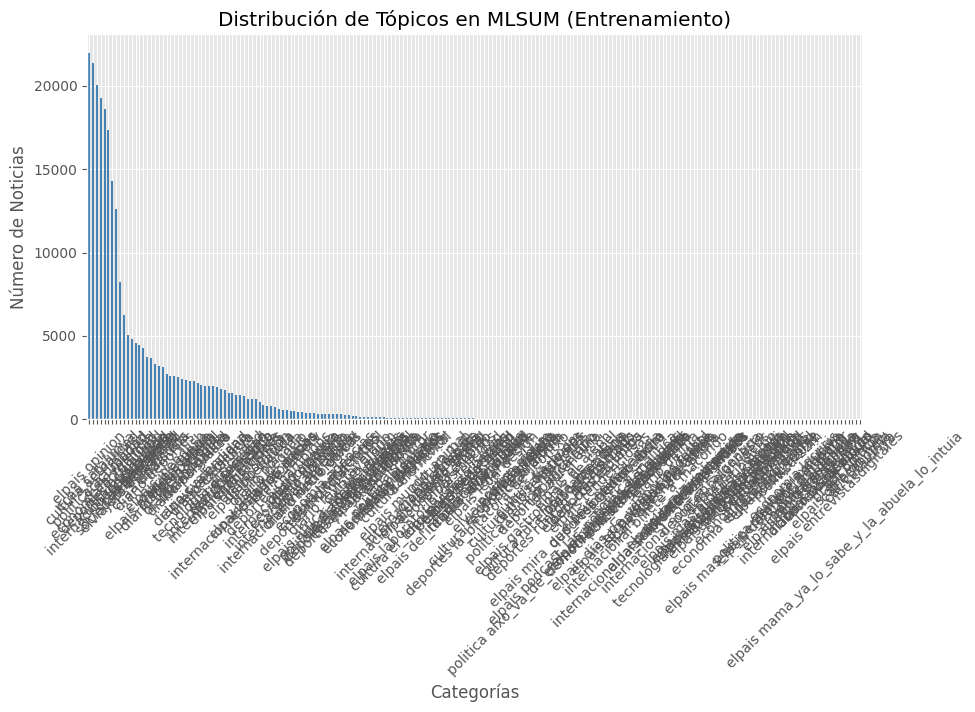

In [10]:
# 2.1 Análisis de Longitud de Textos (aproximación a tokens separando por espacios)
df_train['text_len'] = df_train['text'].apply(lambda x: len(str(x).split()))
df_train['summary_len'] = df_train['summary'].apply(lambda x: len(str(x).split()))

print("--- Estadísticas de Longitud del Texto Original (Palabras) ---")
print(df_train['text_len'].describe())

print("\n--- Estadísticas de Longitud del Resumen (Palabras) ---")
print(df_train['summary_len'].describe())

# 2.2 Distribución de Tópicos
plt.figure(figsize=(10, 5))
df_train['topic'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribución de Tópicos en MLSUM (Entrenamiento)')
plt.xlabel('Categorías')
plt.ylabel('Número de Noticias')
plt.xticks(rotation=45)
plt.show()

## 3.3. Preprocesamiento y Baseline Extractivo (TF-IDF + spaCy)
Implementamos el primer enfoque de resumen: un método extractivo basado en frecuencias (TF-IDF). Extraeremos las oraciones con mayor carga informativa matemática.

In [11]:
# Cargar el modelo lingüístico en español de spaCy
nlp = spacy.load("es_core_news_sm")

def preprocess_sentence(sentence):
    """Limpia una oración: elimina stop-words y puntuación, y devuelve lemas."""
    doc = nlp(sentence.lower())
    clean_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and not token.is_space]
    return " ".join(clean_tokens)

def extractive_summary_tfidf(text, num_sentences=3):
    """Genera un resumen extractivo seleccionando las oraciones más relevantes según TF-IDF."""
    # 1. Dividir texto en oraciones
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    
    if len(sentences) <= num_sentences:
        return text
    
    # 2. Preprocesar las oraciones para calcular TF-IDF
    clean_sentences = [preprocess_sentence(sent) for sent in sentences]
    
    # 3. Calcular TF-IDF de las oraciones
    vectorizer = TfidfVectorizer()
    try:
        tfidf_matrix = vectorizer.fit_transform(clean_sentences)
    except ValueError:
        return " ".join(sentences[:num_sentences]) # Fallback si no hay vocabulario válido
    
    # 4. Puntuar y seleccionar las mejores oraciones
    sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()
    top_indices = sentence_scores.argsort()[-num_sentences:][::-1]
    
    # 5. Ordenar cronológicamente para mantener coherencia narrativa
    top_indices.sort()
    
    summary = " ".join([sentences[i] for i in top_indices])
    return summary

## 3.4. Prueba del Baseline Extractivo
Tomamos una noticia del conjunto de Test (datos que el modelo no ha visto) para evaluar el resultado.

In [12]:
# Seleccionamos la primera noticia del set de test
indice_prueba = 0
texto_ejemplo = df_test['text'].iloc[indice_prueba]
resumen_real = df_test['summary'].iloc[indice_prueba]

# Generamos el resumen
resumen_generado = extractive_summary_tfidf(texto_ejemplo, num_sentences=3)

print("="*60)
print("TEXTO ORIGINAL (Primeros 600 caracteres):")
print("="*60)
print(texto_ejemplo[:600] + "...\n")

print("="*60)
print("RESUMEN GENERADO (Baseline Extractivo TF-IDF):")
print("="*60)
print(resumen_generado + "\n")

print("="*60)
print("RESUMEN DE REFERENCIA (Ground Truth MLSUM):")
print("="*60)
print(resumen_real)

TEXTO ORIGINAL (Primeros 600 caracteres):
Despedida de Rajoy, tras perder la votación de la moción de censura hace un año. En vídeo, así fue la votación de la moción de censura que convirtió a Pedro Sánchez en presidente del Gobierno. Foto: D. GAGO | Vídeo: ATLAS Vista un año después, la moción de censura que cambió la historia de España parece ajedrez, todo calculado. Pero en la semana que tardó en fraguarse, las cosas se parecían mucho más a la carambola de un billar descontrolado. “A Sánchez se le tenían que alinear los planetas para ser presidente. Y se le alinearon. Y eso que venía de las catacumbas”, recuerda, con su habitual hu...

RESUMEN GENERADO (Baseline Extractivo TF-IDF):
Y eso que venía de las catacumbas”, recuerda, con su habitual humor, Aitor Esteban, portavoz en el Congreso del PNV, el partido clave para la salida de Rajoy, al que solo ocho días antes había apuntalado aprobándole los presupuestos. Aquella moción fue el primer paso para llegar al Gobierno y poder cambia

## 4. Evaluación Cuantitativa del Baseline (Métrica ROUGE)
Para comparar de forma justa este modelo extractivo con los futuros modelos generativos, calcularemos las métricas **ROUGE-1, ROUGE-2 y ROUGE-L** sobre una muestra representativa del conjunto de Test.

In [ ]:
%pip install evaluate rouge_score tqdm

import evaluate
from tqdm import tqdm

# 1. Cargar la métrica ROUGE desde Hugging Face
rouge = evaluate.load('rouge')

# 2. Seleccionar una muestra para la evaluación
# Calcular TF-IDF y procesar con spaCy noticia a noticia en CPU lleva un rato.
# Para esta primera prueba, usaremos las primeras 500 noticias del test set.
# (Puedes cambiar este valor a len(df_test) para evaluar el dataset completo)
num_ejemplos = 500
df_muestra = df_test.head(num_ejemplos)

predicciones = []
referencias = df_muestra['summary'].tolist()

print(f"Generando resúmenes extractivos para {num_ejemplos} noticias...")

# 3. Generar los resúmenes con nuestra función del Baseline
for texto in tqdm(df_muestra['text']):
    # Generamos resumen de 3 oraciones (puedes ajustar este hiperparámetro)
    resumen = extractive_summary_tfidf(texto, num_sentences=3)
    predicciones.append(resumen)

# 4. Calcular los scores comparando nuestras predicciones con el 'Ground Truth'
print("\nCalculando métricas ROUGE...")
resultados_rouge = rouge.compute(predictions=predicciones, references=referencias)

# 5. Mostrar los resultados
print("="*60)
print(" RESULTADOS ROUGE - BASELINE EXTRACTIVO (TF-IDF)")
print("="*60)
# Multiplicamos por 100 para verlo en formato porcentaje (0-100)
print(f"ROUGE-1 (Unigramas / Conceptos): {resultados_rouge['rouge1']*100:.2f}")
print(f"ROUGE-2 (Bigramas / Frases):    {resultados_rouge['rouge2']*100:.2f}")
print(f"ROUGE-L (Estructura general):   {resultados_rouge['rougeL']*100:.2f}")
print("="*60)